TASK 3: Handwritten Character Recognition

Objective: Identify handwritten characters or alphabets.

Approach: Use image processing and deep learning.

Key Features:

Dataset: MNIST (digits), EMNIST (characters).

Model: Convolutional Neural Networks (CNN).

Extendable to full word or sentence recognition with sequence modeling (like CRNN).

In [ ]:
# Step-1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step-2 Import libraries
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Step-3 Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


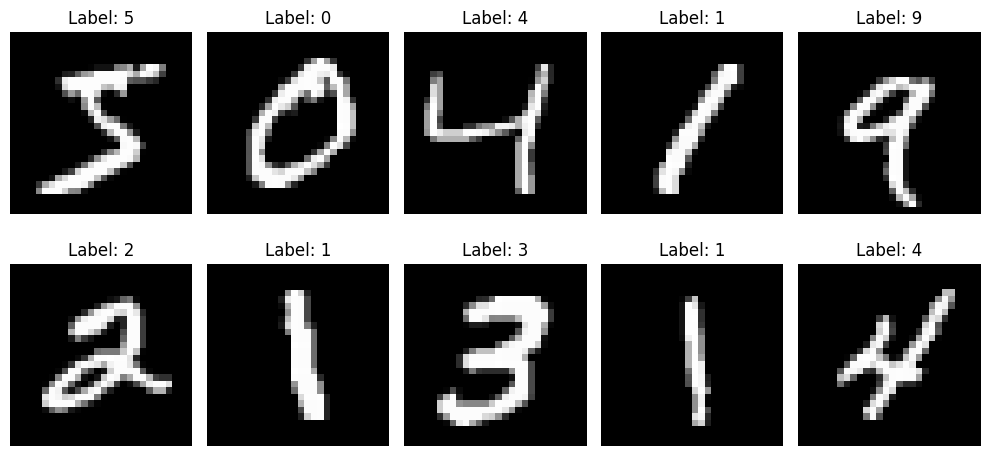

In [ ]:
# Step-4 Display some handwritten images
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Step-5 Image preprocessing
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# Step-6 Reshape the images
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


In [ ]:
# Step-7 Create the CNN model
model = keras.Sequential([

    # Convolutional layer
    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Reduce image size
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolutional layer
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    # Reduce image size again
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Output layer: 10 digits
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 8 — Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Explanation

# Adam
optimizer="adam"
#Loss
loss="sparse_categorical_crossentropy"
#Accuracy
metrics=["accuracy"]

In [ ]:
# Step 9 — Train the CNN
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.9342 - loss: 0.2258 - val_accuracy: 0.9732 - val_loss: 0.0891
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.9808 - loss: 0.0625 - val_accuracy: 0.9867 - val_loss: 0.0496
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.9866 - loss: 0.0442 - val_accuracy: 0.9890 - val_loss: 0.0442
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.9891 - loss: 0.0350 - val_accuracy: 0.9890 - val_loss: 0.0393
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.9918 - loss: 0.0267 - val_accuracy: 0.9893 - val_loss: 0.0410
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.9898 - val_loss: 0.0396
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.9939 - loss: 0.0179 - val_accuracy: 0.9880 - val_loss: 0.0435
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9959 - loss: 0.

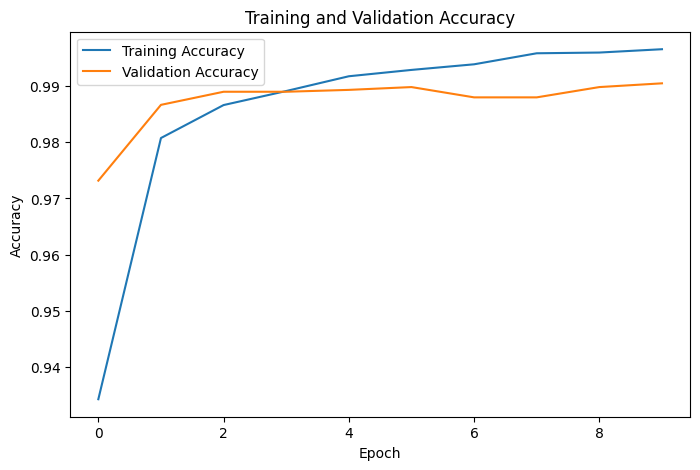

In [ ]:
# Step 10 — Plot training accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

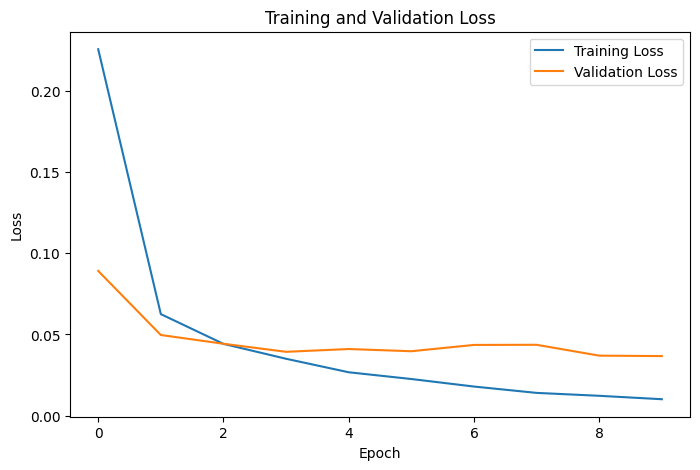

In [ ]:
# Step 11 — Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:
# Step 12 — Evaluate the model
# Now test the CNN on images it has never seen.
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Loss: 0.03285062685608864
Test Accuracy: 0.9901999831199646
Test Accuracy (%): 99.01999831199646


In [ ]:
# Step 13 — Make predictions
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[:20])
print("Actual:   ", y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 5 4]
Actual:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


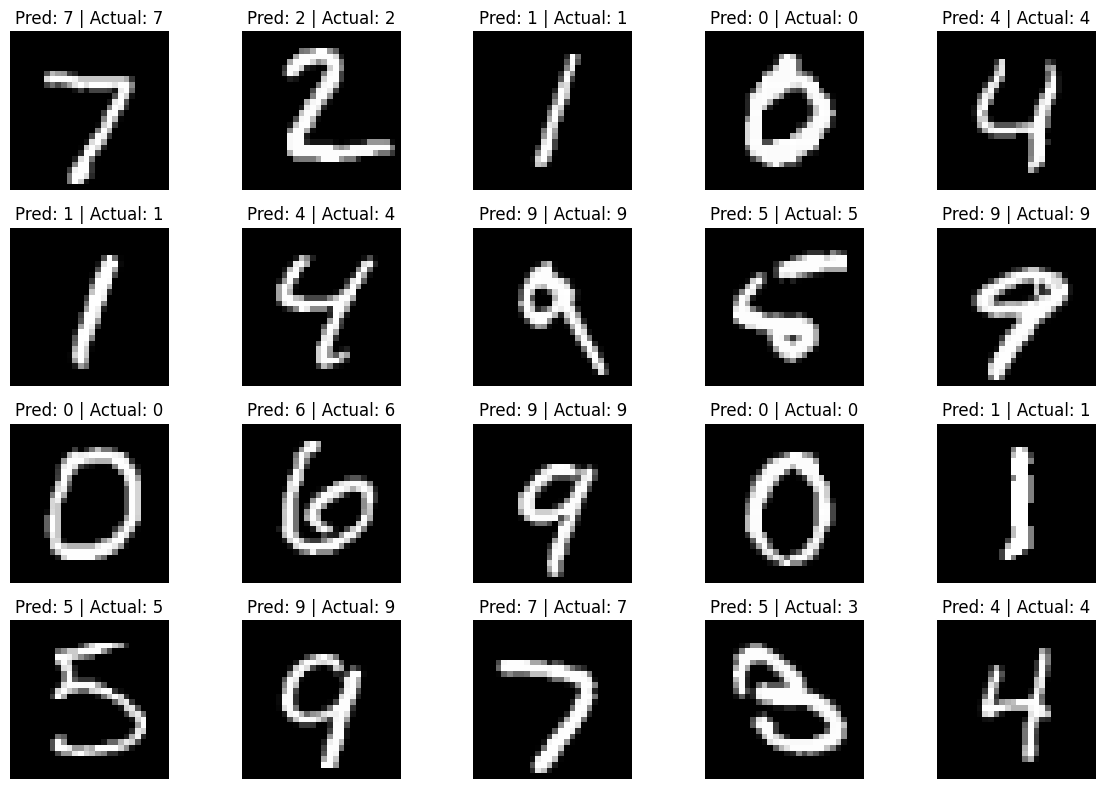

In [ ]:
# Step 14 — Display predictions visually
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap="gray")

    predicted = predicted_labels[i]
    actual = y_test[i]

    plt.title(f"Pred: {predicted} | Actual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

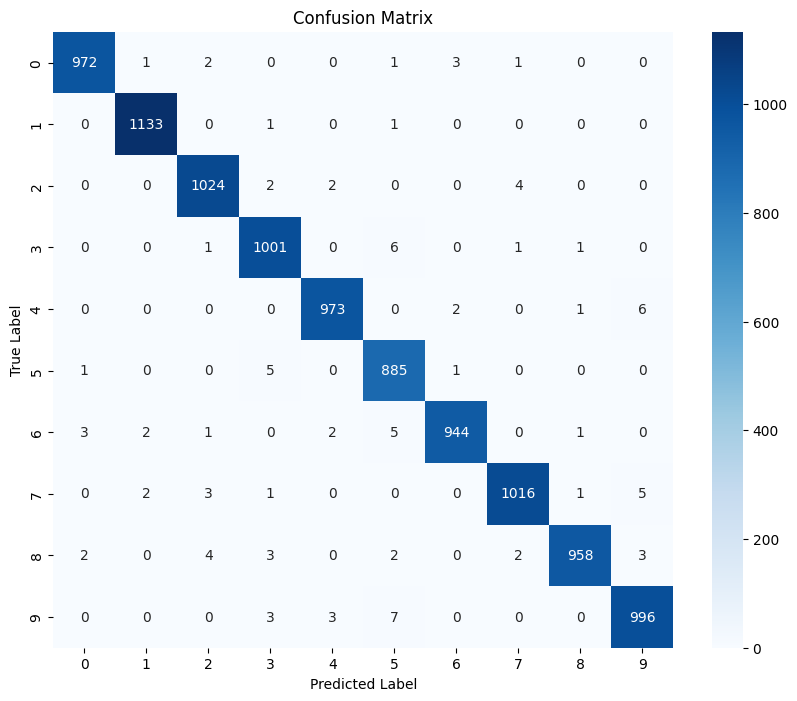

In [ ]:
# Step 15 — Confusion Matrix
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Step 16 — Classification report
print(
    classification_report(
        y_test,
        predicted_labels
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
# Step 18 - Show prediction probability

index = 0

probabilities = model.predict(
    np.expand_dims(x_test[index], axis=0),
    verbose=0
)[0]

for digit, probability in enumerate(probabilities):
    print(f"Digit {digit}: {probability * 100:.2f}%")

Digit 0: 0.00%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 0.00%
Digit 4: 0.00%
Digit 5: 0.00%
Digit 6: 0.00%
Digit 7: 100.00%
Digit 8: 0.00%
Digit 9: 0.00%


In [ ]:
# Step 19 — Save the trained model
model.save("handwritten_digit_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


 Conclusion:
In this project, a Handwritten Character Recognition system was developed using image processing and a Convolutional Neural Network (CNN). The MNIST dataset was used to train and evaluate the model. The images were normalized and reshaped before being provided to the CNN. The model learned important patterns and features from handwritten digits and was able to classify them into the correct classes from 0 to 9. The performance of the model was evaluated using test accuracy, a confusion matrix, and a classification report. The CNN achieved high accuracy on the test dataset, demonstrating that deep learning can be effectively used for handwritten character recognition. The same approach can be extended to the EMNIST dataset for recognizing handwritten alphabets and characters, and further developed for word or sentence recognition using sequence-based models such as CRNN.
